# Ejercicio 1: Filtros pasa-bajos
1. Genere diferentes m´ascaras de promediado, utilizando filtro de promediado o
caja (box filter) y el formato cruz.
Aplique los filtros sobre una imagen y verifique los efectos de aumentar el
tama˜no de la m´ascara en la imagen resultante.
Ayuda: mask = np.ones((3,3),np.float32)/9
2. Genere m´ascaras de filtrado gaussianas con diferente σ y diferente tama˜no.
Visualice y aplique las m´ascaras sobre una imagen. Compare los resultados
con los de un filtro de promediado del mismo tama˜no.
3. Utilice el filtro de mediana sobre una imagen con diferentes tama˜nos de ventana. Compare los resultados con los filtros anteriores para un mismo tama˜no.
4. Los filtros pasa-bajos pueden utilizarse para localizar objetos grandes en una
escena. Aplique este concepto a la imagen ’hubble.tif’ y obtenga una imagen de grises cuyos objetos correspondan solamente a los de mayor tama˜no
de la original.

In [40]:
# Configuración Inicial e Importaciones
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets


In [41]:
def comparar_imagenes(img_1, img_2, titulo_original="Original", titulo_filtrada="Filtrada"):
    fig, axs = plt.subplots(1,2, figsize=(10,5))
    axs[0].imshow(img_1, cmap="gray")
    axs[0].set_title(titulo_original)
    axs[0].axis("off")
    
    axs[1].imshow(img_2, cmap="gray")
    axs[1].set_title(titulo_filtrada)
    axs[1].axis("off")
    
    plt.tight_layout()
    plt.show()

def aplicar_filtro(img, k):
    #hace kernel identidad
    if k%2 ==0:
        k+=1

    kernel = np.ones((k,k), np.float32) / (k*k)
    img_filtrada = cv2.filter2D(img, -1, kernel)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Imagen Original")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(img_filtrada, cmap="gray")
    plt.title(f"Imagen Filtrada (k={k}x{k})")
    plt.axis("off")

def probar_sigma(img, sigma):
    img_gauss = cv2.GaussianBlur(
        src=img,
        ksize=(11,11),   # kernel fijo
        sigmaX=sigma
    )
    
    comparar_imagenes(
        img,
        img_gauss,
        "Original",
        f"Gaussiano sigma={sigma:.1f}"
    )

def probar_mediana(img,kernel_size):
    
    img_mediana = cv2.medianBlur(
        src=img,
        ksize=kernel_size
    )
    
    comparar_imagenes(
        img,
        img_mediana,
        "Imagen con ruido impulsivo",
        f"Mediana {kernel_size}x{kernel_size}"
    )





## 1. Promediado

Box filter: todos los pixeles mismo peso
Cruz: Todos promediados

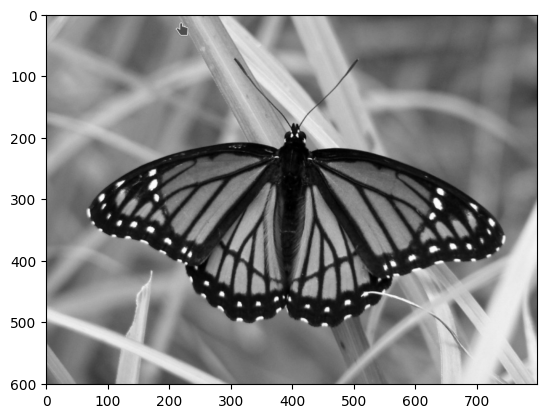

In [42]:
img_prueba = cv2.imread("../Imagenes_cursado/mariposa02.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img_prueba, cmap="gray")
plt.show()

Para aplicar un filtro cualuiera, se tiene que usar la funcion filter2D() util para cualquier kernel

uint8


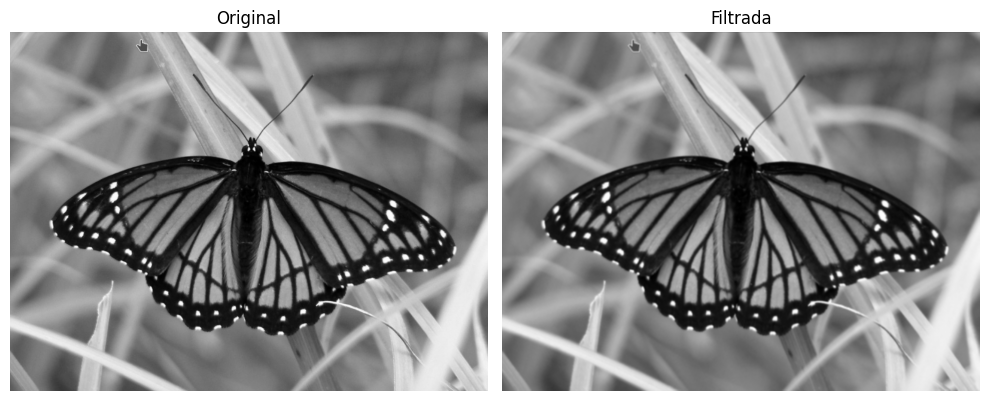

In [43]:
print(img_prueba.dtype)
# este scripts se lo hará con la funcionalidad de hacer la función genérica
mask_full = np.ones(
    (3,3),
    np.float32
)/9

promedio_full= cv2.filter2D(
    src = img_prueba,
    ddepth = -1, # el mismo tipo de dato de la imagen de entrada
    kernel = mask_full
)

comparar_imagenes(img_prueba, promedio_full)



La verdad lucen muy similares. Como intensificamos el promediado?
- Aumentando el tamaño de la matriz
- Usando menos informacion de los vecinos (matriz cruz)

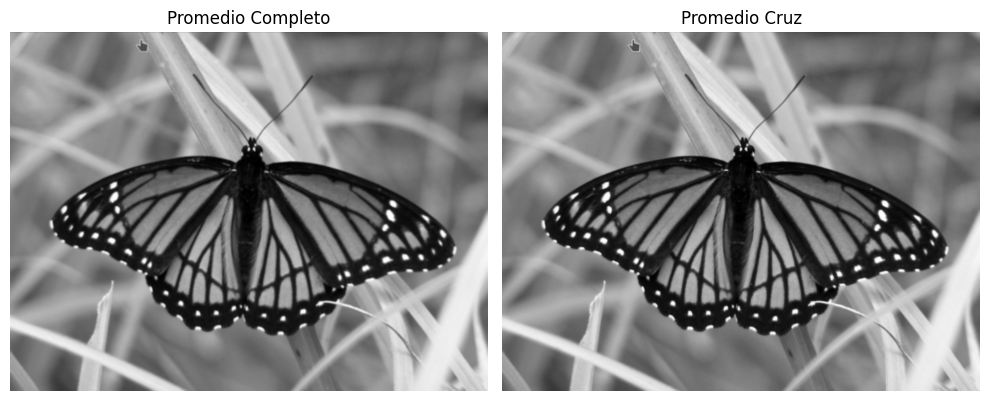

In [44]:
mask_prom = np.array(
    [[0,1,0],
     [1,1,1],
     [0,1,0]], dtype=np.float32
)/5

promedio_cruz = cv2.filter2D(
    src = img_prueba,
    ddepth = -1, # el mismo tipo de dato de la imagen de entrada
    kernel = mask_prom
)

comparar_imagenes(promedio_full, promedio_cruz, titulo_original="Promedio Completo", titulo_filtrada="Promedio Cruz")

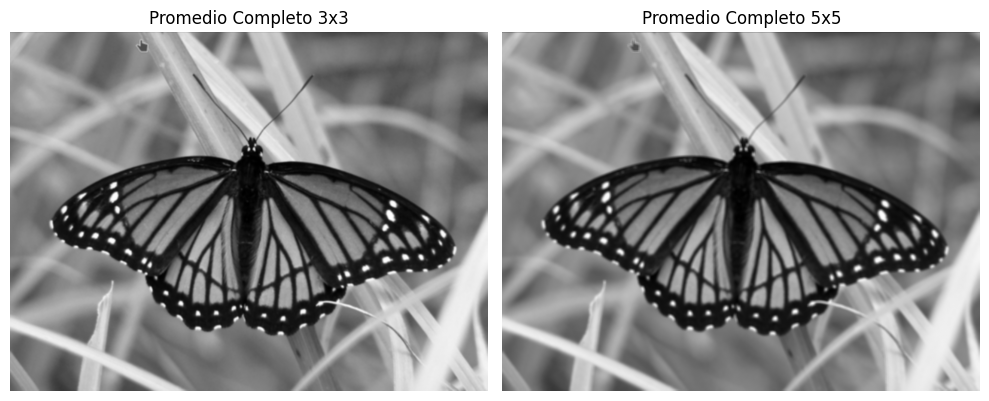

In [45]:
mask_full_5x5 = np.ones(
    (5,5),
    np.float32
)/25

promedio_full_5x5 = cv2.filter2D(
    src = img_prueba,
    ddepth = -1, # el mismo tipo de dato de la imagen de entrada
    kernel = mask_full_5x5
)
comparar_imagenes(promedio_full, promedio_full_5x5, titulo_original="Promedio Completo 3x3", titulo_filtrada="Promedio Completo 5x5")

podemos hacer una idea general para ir deslizando el kernel

In [46]:
interact(
    lambda k: aplicar_filtro(img_prueba, k),
    k=IntSlider(
        min=1,
        max=25,
        step=2,
        value=3
    )
)

interactive(children=(IntSlider(value=3, description='k', max=25, min=1, step=2), Output()), _dom_classes=('wi…

<function __main__.<lambda>(k)>

Los filtros pasa bajos pueden utilizarse pra localizar objetos grandes en una escena, "difuminando" los objetos intrascendentes.

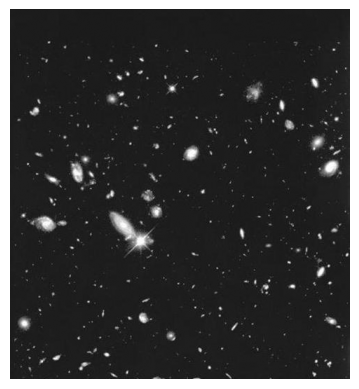

In [47]:
img = cv2.imread("../Imagenes_cursado/hubble.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

nos interesa quedarnos con los objetos grandes, entonces con la informacion local, los objetos pequeños se oscurecerán

In [48]:
interact(
    lambda k: aplicar_filtro(img, k),
    k=IntSlider(
        min=1,
        max=25,
        step=2,
        value=3
    )
)

interactive(children=(IntSlider(value=3, description='k', max=25, min=1, step=2), Output()), _dom_classes=('wi…

<function __main__.<lambda>(k)>

## 2. Filtrado gaussiano
Un filtor gaussiano:
- Pixel central pesa mas
- Vecinos cercanos pesan bastante
- Vecinos lejanos menos
Siguen una distribucion gaussiana
Difumina mas las alatas frecuencias y "deforma" menos la imagen

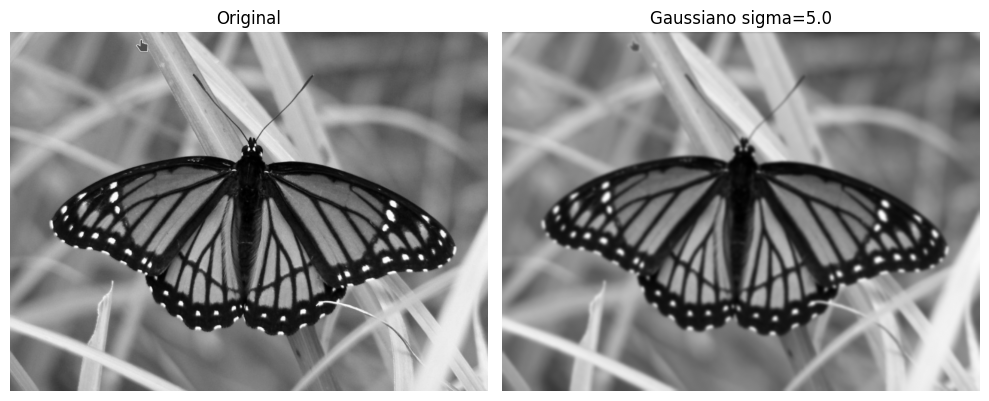

In [67]:
img = cv2.imread("../Imagenes_cursado/mariposa02.png", cv2.IMREAD_GRAYSCALE)

img_gauss = cv2.GaussianBlur(
    src=img,
    ksize=(11,11),   # kernel fijo
    sigmaX=2
)
comparar_imagenes(
    img,
    img_gauss,
    "Original",
    "Gaussiano sigma=5.0"
)

## comparaciones gaussianos vs promediados 7x7
Vamos a comparar con la misma matriz ambos resultados

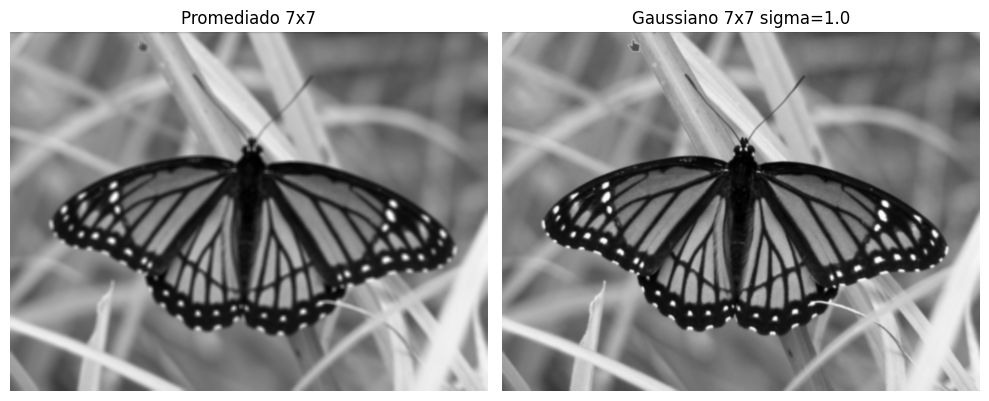

In [50]:
mask_7x7= np.ones(
    (7,7),
    np.float32
)/49

promediado_7x7 = cv2.filter2D(
    src = img,
    ddepth = -1, # el mismo tipo de dato de la imagen de entrada
    kernel = mask_7x7
)

img_gauss_7x7 = cv2.GaussianBlur(
    src=img,
    ksize=(7,7),   # kernel fijo
    sigmaX=1.0
)

comparar_imagenes(
    promediado_7x7,
    img_gauss_7x7,
    titulo_original="Promediado 7x7",
    titulo_filtrada="Gaussiano 7x7 sigma=1.0"
)



Podedmos ver que el filtro gaussiano pierde muchisima menos caldiad de los "objetos importantes".

## 3. Filtro de mediana
Util para limipiar ruidos extremos impulsivos

In [51]:
img = cv2.imread("../Imagenes_cursado/mariposa02.png", cv2.IMREAD_GRAYSCALE)

interact(
    lambda kernel_size: probar_mediana(img, kernel_size),
    kernel_size=IntSlider(
        min=1,
        max=25,
        step=2,
        value=3
    )
)


interactive(children=(IntSlider(value=3, description='kernel_size', max=25, min=1, step=2), Output()), _dom_cl…

<function __main__.<lambda>(kernel_size)>

Parece como pintura al oleo lol

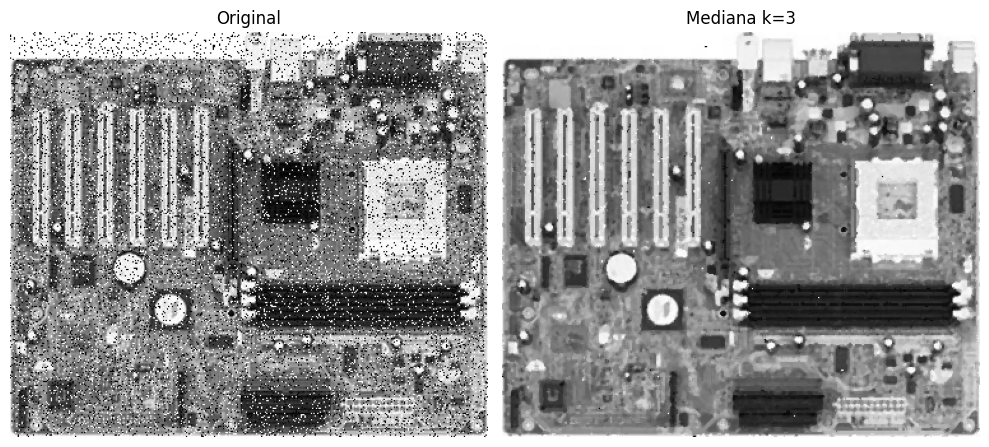

In [52]:
img = cv2.imread("../Imagenes_cursado/a7v600-X(RImpulsivo).gif", cv2.IMREAD_GRAYSCALE)

img_filtrada= cv2.medianBlur(
    src=img,
    ksize=3
)

comparar_imagenes(img, img_filtrada, titulo_original="Original", titulo_filtrada="Mediana k=3")





## ejercicio 4 Localizacion


In [53]:
img = cv2.imread("../Imagenes_cursado/hubble.tif", cv2.IMREAD_GRAYSCALE)

In [54]:
# deteccion promedio

interact(
    lambda k: aplicar_filtro(img, k),
    k=IntSlider(
        min=1,
        max=25,
        step=2,
        value=3
    )
)

interactive(children=(IntSlider(value=3, description='k', max=25, min=1, step=2), Output()), _dom_classes=('wi…

<function __main__.<lambda>(k)>

In [55]:
# Deteccion gaussiana

interact(
    lambda sigma: probar_sigma(img, sigma),
    sigma=FloatSlider(
        min=0.1,
        max=10.0,
        step=0.1,
        value=1.0
    )
)

interactive(children=(FloatSlider(value=1.0, description='sigma', max=10.0, min=0.1), Output()), _dom_classes=…

<function __main__.<lambda>(sigma)>

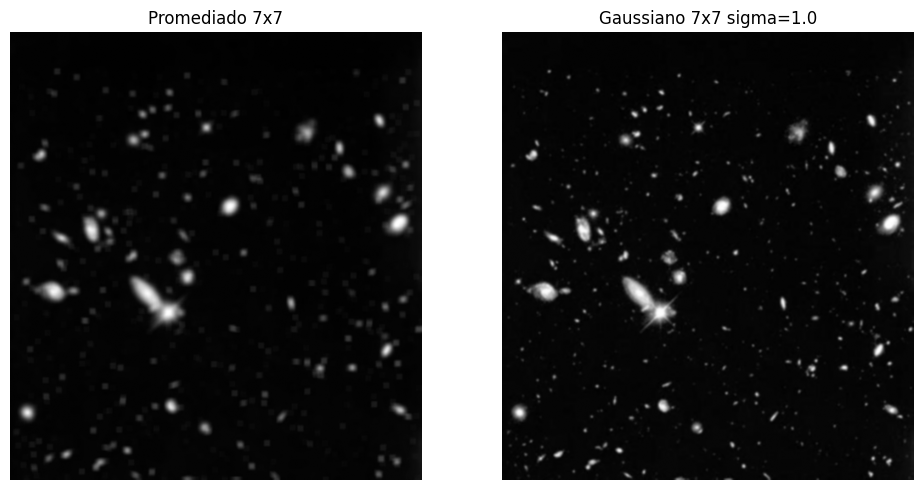

In [56]:
# comparamos ambos filtros
mask_7x7= np.ones(
    (7,7),
    np.float32
)/49

promediado_7x7 = cv2.filter2D(
    src = img,
    ddepth = -1, # el mismo tipo de dato de la imagen de entrada
    kernel = mask_7x7
)

img_gauss_7x7 = cv2.GaussianBlur(
    src=img,
    ksize=(7,7),   # kernel fijo
    sigmaX=1.0
)

comparar_imagenes(
    promediado_7x7,
    img_gauss_7x7,
    titulo_original="Promediado 7x7",
    titulo_filtrada="Gaussiano 7x7 sigma=1.0"
)



In [57]:
# deteccion mediana

interact(
    lambda kernel_size: probar_mediana(img, kernel_size),
    kernel_size=IntSlider(
        min=1,
        max=25,
        step=2,
        value=3
    )
)

interactive(children=(IntSlider(value=3, description='kernel_size', max=25, min=1, step=2), Output()), _dom_cl…

<function __main__.<lambda>(kernel_size)>

Mucho mas fuerte